In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

In [5]:
datasS0 = [np.load("sigma_0_Mult_Galo_%s.npy"%i, allow_pickle=True) for i in range(2)] #22

#### Phase plot

In [6]:
import matplotlib as mpl
import Modules.EnergyMass as en


from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap

In [7]:
# Checking that all configurations have the same mass up to the first decimal point.
LambT, gamma = 0, 0
datosTemp = []
datosMasa = []
print('#'*10)
for s0 in datasS0:
    MT, EnT = 0, 0
    pdata, temp = [], []
    for data in s0:
        Ei, rad, sDnew, dsDnew, uDnew, duDnew = data
        Masa = en.massVal(rad, sDnew**2)
        arg2 = [LambT, gamma]  # Calculando la masa de la componente
        Enf, _, _ = en.EnFuncion([rad, sDnew, None], arg2)  # Calculando la energía de la componente
    
        MT += Masa  # Calculando la masa total
        EnT += Enf  # Calculando la energía total
        
        temp.append(Masa)
        pdata.append(sDnew[0])
        
    print('Masa = %4.1f'%MT)
    datosTemp.append(np.concatenate(([MT, EnT], pdata)))  # Guardando los datos
    datosMasa.append(temp)
print('#'*10)

datosSig0EnMas = []
datosSig0EnMas.append(np.array(datosTemp))  # Convierte y almacena los datos

##########
Masa = 43.4
Masa = 43.5
##########


In [8]:
datosMasa

[[43.352803087146604, 0.0661138333988271, 0.0],
 [40.850573236687154, 2.659587255510099, 0.0]]

### Stability 

In [9]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

In [10]:
# datasS0

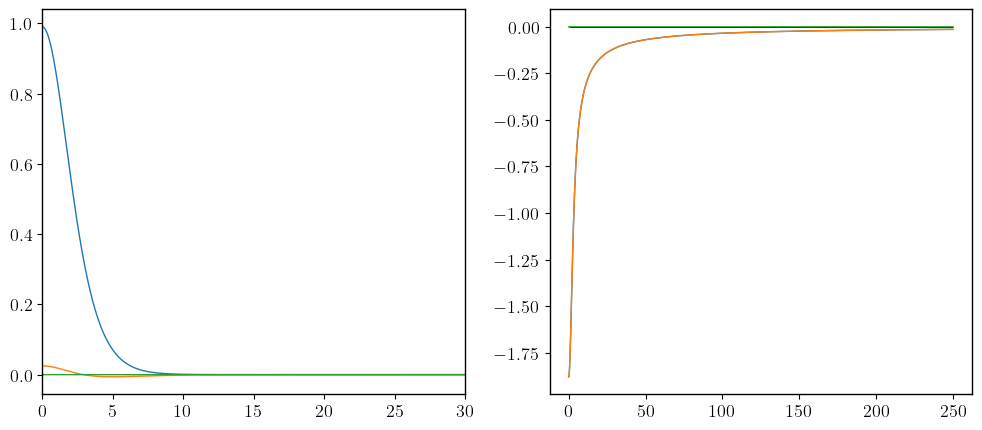

In [11]:
# perf 0
# Debo recuperar los resultados de la polarización linal con n=0

datE = []
datFunc = [[], []]
for s0dat in datasS0[0]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 0
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
#ax[0].set_yscale('log')
plt.show()

lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [12]:
for ind, [Jval, data] in enumerate(dataExtra):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[ 2.0236257e-07-4.19892194e-10j -2.0236257e-07+4.19955580e-10j]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]


Text(0, 0.5, '$\\lambda_I$')

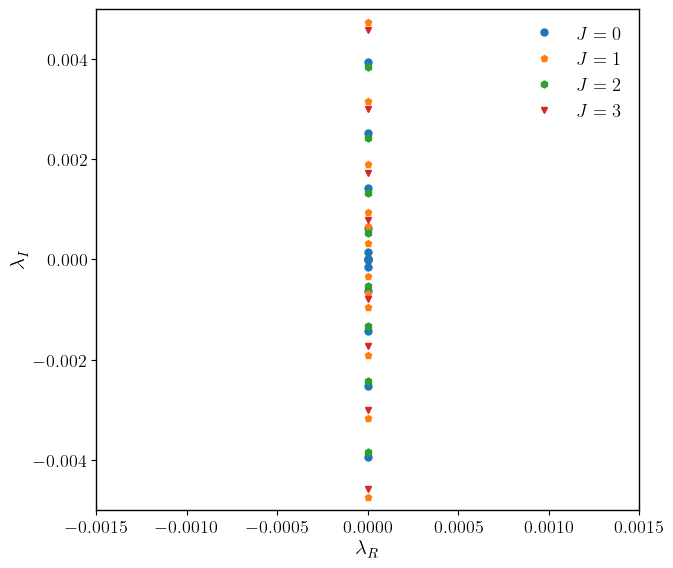

In [13]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtra):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
ax.set_xlim(-0.0015, 0.0015)
ax.set_ylim(-.005, .005)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

Jval = 0
[ 2.0236257e-07-4.19892194e-10j -2.0236257e-07+4.19955580e-10j]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]


/var/folders/mf/vfyq6zyn4l35gfd2kgq4k2q00000gn/T/ipykernel_8875/1472118095.py:35: ComplexWarning: Casting complex values to real discards the imaginary part
  ax[0][0].text(x=20, y=-0.05, s=r'%8.7f'%eingVal[ind][0])
/var/folders/mf/vfyq6zyn4l35gfd2kgq4k2q00000gn/T/ipykernel_8875/1472118095.py:36: ComplexWarning: Casting complex values to real discards the imaginary part
  ax[1][0].text(x=20, y=-0.05, s=r'%8.7f'%eingVal[ind][1])


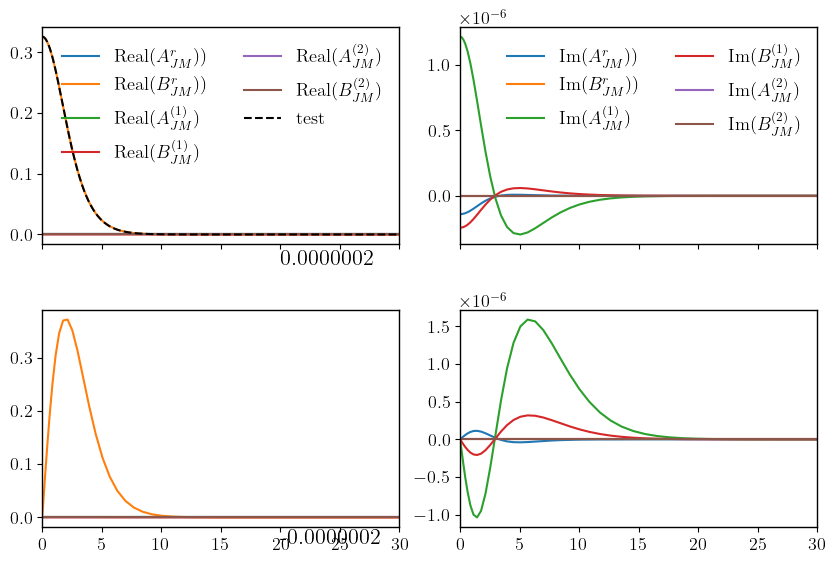

In [14]:
# validando q es trivial

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6.5),
                       sharex=True, sharey=False,
                       gridspec_kw=dict(hspace=0.3, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )

# dataExtra.append([J, list([r_dis2, LambdaRealSorted, eig_vectors_sorted[:, jj]])])
for ind, [Jval, data] in enumerate(dataExtra):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)    
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])
    
    if Jval==0:
        labels = ['$A_{JM}^{r}$)', '$B_{JM}^{r})$', '$A_{JM}^{(1)}$', '$B_{JM}^{(1)}$', '$A_{JM}^{(2)}$', '$B_{JM}^{(2)}$']
        datay = (eigVect[:, ind])[:, 0]
        for i in range(6):
            ax[0][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)])/rdis, label=r'Real(%s)'%labels[i])  # notar que /rdis
            ax[0][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)])/rdis, label=r'Im(%s)'%labels[i])
        
        i = 1
        valc = (np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)])/rdis)[0]/datFunc[0][0](0)
        ax[0][0].plot(rad, datFunc[0][0](rad)*valc, c='k', ls='--', label='test')
        # ax[0][1].plot(rad, datFunc[0][1](rad)*0.302, c='k', label='test')
        
        ax[0][0].legend(frameon=False, fontsize='small', ncol=2)
        ax[0][1].legend(frameon=False, fontsize='small', ncol=2)
        
        datay = (eigVect[:, ind])[:, 1]
        for i in range(6):
            ax[1][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[1][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])
        
        ax[0][0].text(x=20, y=-0.05, s=r'%8.7f'%eingVal[ind][0])
        ax[1][0].text(x=20, y=-0.05, s=r'%8.7f'%eingVal[ind][1])
        ax[0][0].set_xlim(0, 30)
        ax[0][1].set_xlim(0, 30)
        #ax[0][0].set_ylim(-0.002, 0.002)

In [15]:
# Primera fila es el r*A, segunda fila es solo A, donde A sería el modo

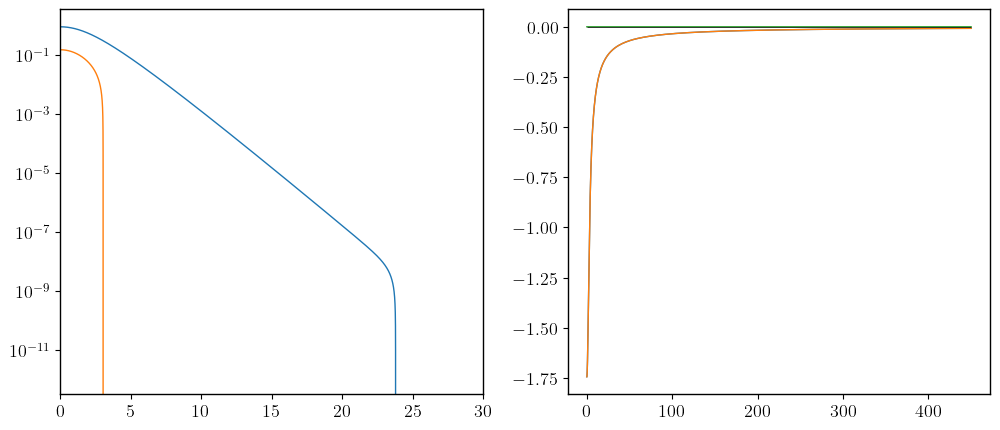

In [16]:
# perf 1

datE = []
datFunc = [[], []]
for s0dat in datasS0[1]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn1, dataExtran1 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [17]:
for ind, [Jval, data] in enumerate(dataExtran1):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[ 0.00178135-0.13755687j -0.00178135-0.13755687j  0.00178135+0.13755687j
 -0.00178135+0.13755687j]
Jval = 2
[]
Jval = 3
[]


Text(0, 0.5, '$\\lambda_I$')

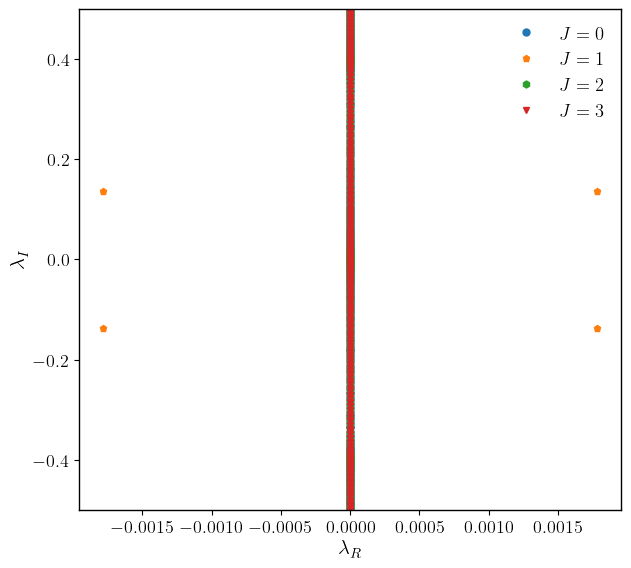

In [18]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran1):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.0015, 0.0015)
ax.set_ylim(-.5, .5)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [19]:
# Eingevalues
data = [dataExtra, dataExtran1]

In [20]:
JModes = [[], [], [], []]
JVect = [[], [], [], []]
for dat in data:
    for ind, [Jval, data2] in enumerate(dat):
        rdis, eingVal, eigVect = data2
        # print('Jval = %d'%Jval)
        ind2 = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
        # print(eingVal[ind2])
        
        JModes[ind].append(eingVal[ind2])
        JVect[ind].append([rdis, eigVect[:, ind]])
        

In [21]:
totalM = np.sum(datosMasa, axis=1)
totalM

array([43.41891692, 43.51016049])

Text(0, 0.5, '$\\lambda_R$')

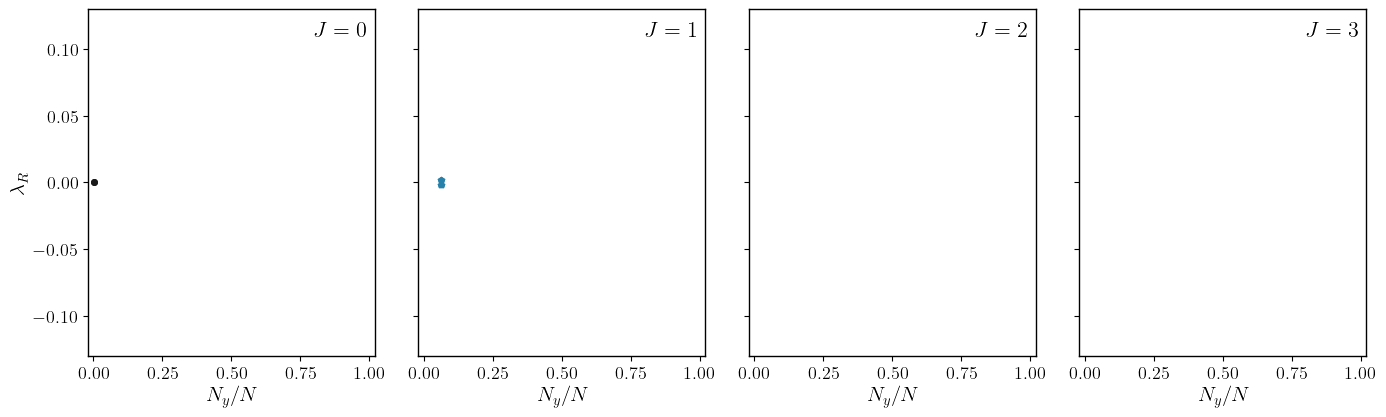

In [22]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
mark = ['o', 'p', 'h', 'v']
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16.5, 4.5),
                       sharex=False, sharey=True,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

for i in range(4):
    for j in range(2):
        modos = JModes[i][j]
        ax[i].plot([(datosMasa[j][1]/totalM[j])]*len(modos), np.real(modos), ls='', marker=mark[i], c=col[i], markersize='4')
        

for ind, axes in enumerate(ax):
    axes.text(x=0.8, y=0.11, s=r'$J=%d$'%ind)
    axes.set_xlim(-0.02, 1.02)
    axes.set_ylim(-0.13, .13)
    axes.set_xlabel(r'$N_y/N$')

ax[0].set_ylabel(r'$\lambda_R$')

#jv = 1
#xR = (datosMasa[jv][1]/totalM[jv])
#ax[0].vlines(x=xR, ymin=-0.2, ymax=0.2, ls='--', color=col[0], alpha=0.2)

#_, _, sDnewx, _, _, _ = datasS0[jv][0]
#_, _, sDnewy, _, _, _ = datasS0[jv][1]
#ax[0].text(x=xR-0.055, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=12, rotation=90)

In [30]:
j = 1
(datosMasa[j][1]/totalM[j])

0.061125659510887054

In [ ]:
# Los que me dieron a mi fueron razones de:

0.06112540403922411
0.08771356024349293
0.12263982346083628
0.17221934658635038